In [1]:
import numpy as np
import torch
from scipy import stats
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from collections import defaultdict

import sys
sys.path.append('../../src')
root = Path('../../src')
from utils.yaml import parse_yaml
from utils.utils import load_checkpoint
from data.transforms import numpy_to_floattensor, numpy_to_doubletensor
from metrics.testing import hsic
from kernel.gaussian import Gaussian
device = torch.device('cuda:0')

In [2]:
k = Gaussian(1., 1.).to(device)
l = Gaussian(1., 1.).to(device)
k.eval(); l.eval()

# dataset_cfg = root/"config/dataset/hdgm/hdgm2-generator.yml"
# dataset_cfg = root/"config/dataset/sinusoid/sinusoid-f2-generator.yml"
# dataset_cfg = root/"config/dataset/isa/isa.d=1.std=0.1.rot=0.5.yml"
dataset_cfg = root/"config/dataset/isa/isa.d=3.std=0.1.rot=0.4.yml"

dataconfig = parse_yaml(dataset_cfg)['test']
if 'root' in dataconfig:
    dataconfig['root'] = root/dataconfig['root']
dataconfig['transform'] = numpy_to_floattensor
dataset = dataconfig.build()

def stream(dataloader):
    while True:
        yield from dataloader

In [3]:
ALPHA = 0.05
REG = 1e-8
NBAND = 1000
NPERM = 500
NTEST = 100
TESTSIZE = 250 #250

log_wxs = np.linspace(-20, 5, num=NBAND)
dataloader = DataLoader(dataset, batch_size=TESTSIZE)
dataiter = iter(dataloader)

X, Y = next(dataiter)
X = X.to(device)
Y = Y.to(device)
del dataloader
del dataiter

## Objective Curve

In [4]:
# use first test batch
snrs_wo = np.full(NBAND, np.nan)
snrs_w = np.full(NBAND, np.nan)
max_wo = (None,-999)
max_w = (None,-999)
db = defaultdict(lambda: np.full(NBAND, np.nan))

for i, log_wx in tqdm(enumerate(log_wxs), total=NBAND):

    k.bandwidth = np.exp(log_wx)
    Kxx = k(X,X)
    Lyy = l(Y,Y)
    m = Kxx.shape[-1]

    # compute snr w/o thresh
    hsic_est, var_est = hsic.hsic_fast(Kxx, Lyy, statistic='v', compute_var=True)
    hsic_est = hsic_est.cpu().numpy()
    var_est = var_est.cpu().numpy()
    J_est = hsic_est / np.sqrt(var_est + REG)
    snrs_wo[i] = J_est

    # compute snr w/ thresh
    e0 = hsic.null_mean(Kxx, Lyy).cpu().numpy()
    v0 = hsic.null_var(Kxx, Lyy).cpu().numpy()
    shape = e0**2 / v0
    scale = v0 / e0
    r = stats.gamma.ppf(1-ALPHA, shape, scale=scale)
    J_est_w = (hsic_est - r/m) / np.sqrt(var_est + REG)
    snrs_w[i] = J_est_w

    # save maximums
    if J_est > max_wo[1]:
        max_wo = (log_wx, J_est)
    if J_est_w > max_w[1]:
        max_w = (log_wx, J_est_w)

    # misc stats
    db['hsic'][i] = hsic_est
    db['var'][i] = var_est
    db['thresh'][i] = r
    db['e0'] = e0
    db['v0'] = v0

100%|██████████| 1000/1000 [00:01<00:00, 848.72it/s]


## Test Powers

In [ ]:
@torch.no_grad()
def dist2(X: torch.Tensor):
    assert X.ndim >= 2
    norm2 = torch.sum(X**2, dim=-1, keepdim=True)
    return torch.clamp(norm2 - 2 * X @ X.mT + norm2.mT, min=0)

@torch.no_grad()
def hsic_b(Kxx: torch.Tensor, Lyy: torch.Tensor):
    assert Kxx.ndim >= 2 and Lyy.ndim >= 2 and Kxx.shape[-2:] == Lyy.shape[-2:]
    m = Kxx.shape[-1]
    c1 = torch.mean(Kxx * Lyy, dim=(-2,-1))
    c2 = - (2/(m**3)) * torch.einsum('...ij,...ir->...', Kxx, Lyy)
    c3 = torch.mean(Kxx, dim=(-2,-1)) * torch.mean(Lyy, dim=(-2,-1))
    return c1 + c2 + c3

dataloader = DataLoader(dataset, batch_size=TESTSIZE)

power_at_bandwidth = np.full(NBAND, np.nan)
for i, log_wx in tqdm(enumerate(log_wxs), total=NBAND):

    p_vals = np.empty(NTEST)
    for t, data in zip(range(NTEST), dataloader):
        X = data[0].to(device)
        Y = data[1].to(device)
        hsic_est, _, p_value, _ = hsic.permutation_test(k, l, X, Y, statistic='v', n_permutations=NPERM, significance=ALPHA)
        p_vals[t] = p_value

    power_at_bandwidth[i] = (p_vals < ALPHA).mean()

# np.save('power_at_bandwidth_tmp', power_at_bandwidth)

In [ ]:
power_at_bandwidth = np.load('power_at_bandwidth.npy')
power_at_bandwidth

In [ ]:
fig, axes = plt.subplots(1, 2, squeeze=True, layout='constrained', figsize=(12, 5),)

axes[0].plot(log_wxs, snrs_wo, linewidth=2, label='w/o threshold')
axes[0].plot(log_wxs, snrs_w, linewidth=2, label='w/ threshold')
axes[0].set_title("")
axes[0].set_xlabel(r'Log-bandwidth ($\log\omega_X$)')
axes[0].set_ylabel(r'SNR objective')
axes[0].legend() #loc='lower left')

# axes[1].plot(log_wxs, power_at_bandwidth, linewidth=2,)
# axes[1].set_title("")
# axes[1].set_xlabel(r'Log-bandwidth ($\log\omega_X$)')
# axes[1].set_ylabel('permutation test power') #('permutation test power')   #(r'Threshold via Gamma approx.')
# axes[1].legend()

# axes[1].set_ylim([0, 1])
# plt.savefig('isa-m=250 (10).pdf', bbox_inches='tight')

(5.0, -0.0007251962379343839)


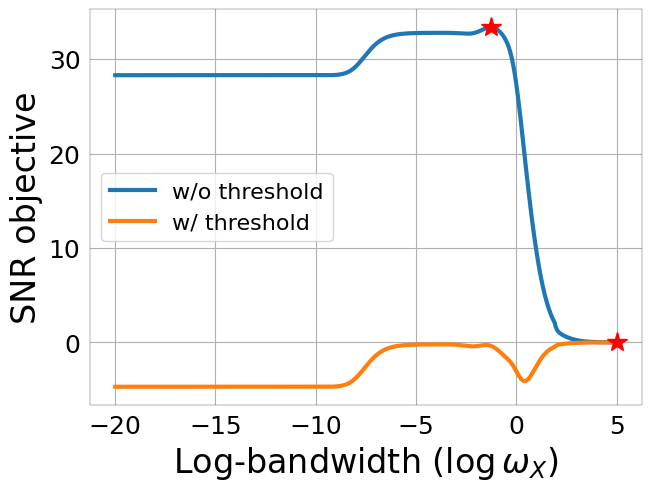

In [ ]:
fig, ax = plt.subplots(squeeze=True, layout='constrained') #, figsize=(12, 5),)

ax.plot(log_wxs, snrs_wo, linewidth=3, label='w/o threshold')
ax.plot(log_wxs, snrs_w, linewidth=3, label='w/ threshold')
ax.plot(*max_wo, 'r*', markersize=15,)
ax.plot(*max_w, 'r*', markersize=15,)
ax.set_title("")
ax.set_xlabel(r'Log-bandwidth ($\log\omega_X$)', fontsize=24)
ax.set_ylabel(r'SNR objective', fontsize=24)
ax.legend(fontsize=16)

plt.grid()
plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)

# plt.savefig('isa-m=250 (7).pdf', bbox_inches='tight')

## TODO

- try different test sizes (m=250, 500, 1000, 2000, etc...)
- plot test power (via permutation) at each log-bandwidth